In [1]:
from collections import defaultdict
import json
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Using a Leave-One-Out strategy, the naive bayes model will be trained
# with all of the data except for the data being predicted on.

# This function returns the information needed to make predictions on 
# the message with msg_id = test_id

def load_corpus(test_id, messages):
    corpus_vocab = set()
    labels = [
        "attendence", "grade_dispute", "academic_integrity", "accommodation_request" ,
        "advising/enrollment", "deadline_extension", "technical/LMS_issue"
    ]
    class_word_counts = { label: defaultdict(int) for label in labels}
    class_instance_counts = defaultdict(int)

    class_totals = defaultdict(int)
    vocab_size = len(corpus_vocab)

    for m in messages:
        if m['msg_id'] == test_id:
            continue
        text = m['text']
        label = m['label']
        for word in text.split(' '):
            # Add word to corpus vocab
            corpus_vocab.add(word)
            # add word to class instance count
            class_instance_counts[label] += 1

            # Add word to class word counts
            class_word_counts[label][word] += 1 
            class_totals[label] += 1
    
    class_priors = { label : count / (len(messages) - 1) for label, count in class_totals.items() }
            
    return vocab_size, class_word_counts, class_totals, class_priors

# This function calcaultes values propoertional to the log probability of each class
# given the document text and returns the class with the highest value
def predict_class(message, class_word_counts, class_totals, vocab_size, class_priors):
    text = message['text']
    possible_class_labels = list(class_word_counts.keys())

    log_probs = {}
    for label in possible_class_labels:
        log_prob = 0
        for word in text.split():
            class_word_count = class_word_counts[label][word]
            class_total = class_totals[label]
            
            # Use add one smoothing to calculate P( w_i | c )
            log_prob += np.log( (class_word_count + 1) / (class_total + vocab_size) )
            
        log_probs[label] = log_prob + np.log(class_priors[label])
    
    return max(log_probs, key=log_probs.get)


academic_integrity recall: 1.0
academic_integrity precision: 0.75

accommodation_request recall: 0.6666666666666666
accommodation_request precision: 0.5714285714285714

advising/enrollment recall: 0.8333333333333334
advising/enrollment precision: 0.7142857142857143

attendence recall: 0.6666666666666666
attendence precision: 0.8

deadline_extension recall: 0.8333333333333334
deadline_extension precision: 1.0

grade_dispute recall: 0.6666666666666666
grade_dispute precision: 1.0

technical/LMS_issue recall: 0.8333333333333334
technical/LMS_issue precision: 0.8333333333333334

Macro F1: 0.7976063586807564


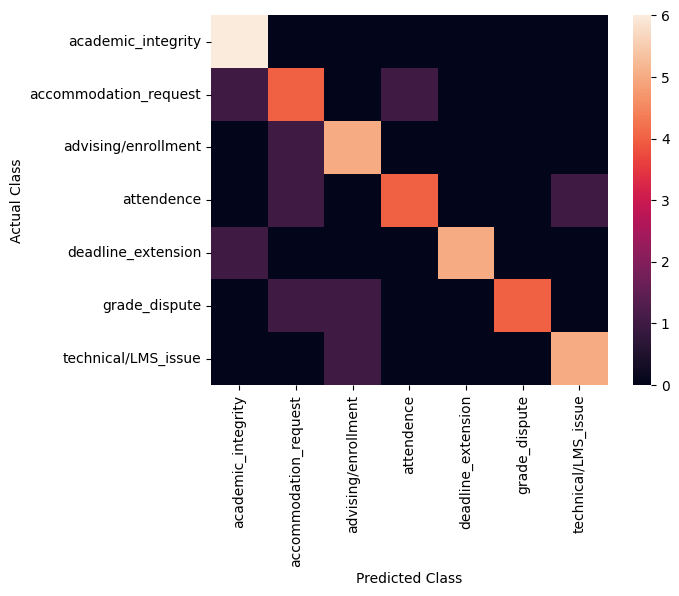

In [ ]:
# Calculates and displays model error statistics
def stats(df):
    cm = confusion_matrix(df["label"], df['prediction'])
    labels = df["label"].sort_values().unique().tolist()

    TP = cm.diagonal()
    FP = cm.sum(axis=0) - TP 
    FN = cm.sum(axis=1) - TP
    for i, l, in enumerate(labels):
        print(f"{l} recall:", TP[i]/(TP[i] + FN[i]))
        print(f"{l} precision:", TP[i]/(TP[i] + FP[i]))
        print()

    macro_recall = np.mean(TP/(TP + FN))
    macro_precision = np.mean(TP/(TP + FP))
    print(f"Macro F1:", (2 * macro_precision * macro_recall) / (macro_precision + macro_recall)  )

    sns.heatmap(cm, xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.show()

    
### PREDICTOINS TAKE PLACE HERE
messages = []
with open("data/4_student_message.jsonl", "r") as file:
    for line in file:
        clean = line.strip()
        messages.append(json.loads(clean))
        
# Loops through each document and classifies
for message in messages:
    msg_id = message["msg_id"]
    vocab_size, class_word_counts, class_totals, class_priors = load_corpus(msg_id, messages)
    
    class_prediction = predict_class(message, class_word_counts, class_totals, vocab_size, class_priors)
    message["prediction"] = class_prediction

df = pd.DataFrame(messages)
stats(df)

In [15]:
incorrect = df[df["label"] != df["prediction"]]

for i, row in incorrect.iterrows():
    print(row["msg_id"], ": ", row["text"])
    print("True Label:", row["label"], "  Predicted Label:", row["prediction"])
    print()

2 :  Dear Instructor please excuse my absence from today's lecture as I have come down with a sudden illness and need to visit the health clinic
True Label: attendence   Predicted Label: accommodation_request

5 :  Professor I am so sorry for missing yesterday's session as I experienced some unexpected car trouble on my way to campus and could not make it
True Label: attendence   Predicted Label: technical/LMS_issue

8 :  Hello I would like to schedule a time to discuss my recent exam results because I believe there may have been an error in how question four was scored
True Label: grade_dispute   Predicted Label: accommodation_request

9 :  Hi I am confused about the points deducted from my last lab report and was hoping you could clarify the specific grading criteria used for the conclusion
True Label: grade_dispute   Predicted Label: advising/enrollment

19 :  Hello Professor I am an authorized student with the disability services office and I have attached my official letter regard

Many of examples mislabled as accomodation_requests contain requests "please excuse","I would like", "I am writing to ask". It makes sense why the model thought they were accomodation requests.

Both of the examples misclassified as advisin/enrollment contain the word "hoping". This word may be common in the class because students are "hoping" to enroll in this or that class

Message 5 was misclassified as technical/LMS_issue, which makes sense because it discusses "car trouble" as a reason for not attending class.